In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\vinut\OneDrive\ドキュメント\ML Projects\Student-Performance-Prediction\data\StudentPerformance.csv")

In [4]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
#EDA
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [7]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
    "Yes": 1,
    "No": 0
})

In [8]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


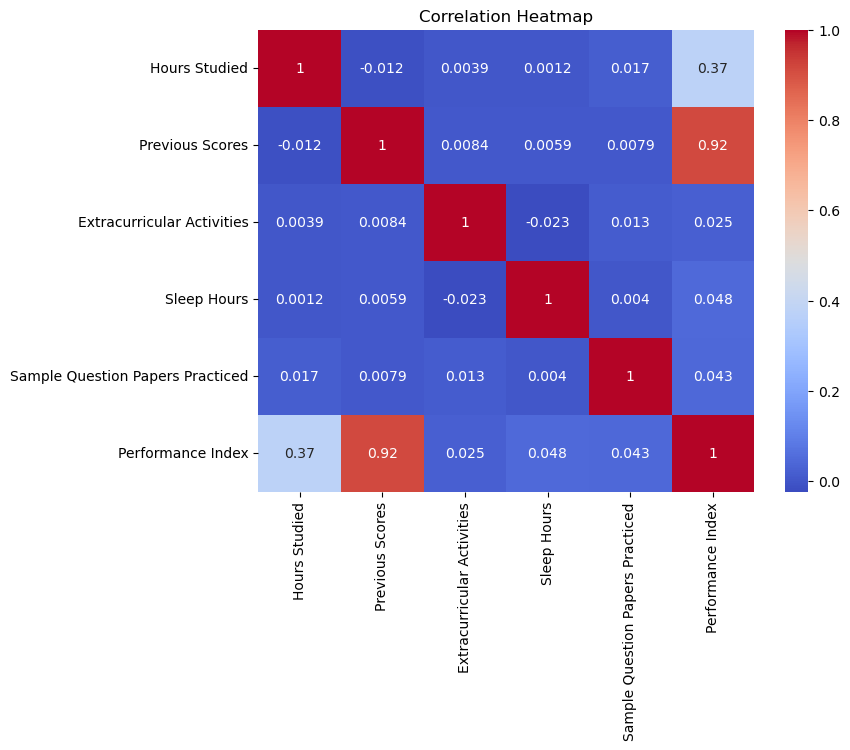

In [9]:
#EXPLORATORY DATA ANALYSIS
#HOURS STUDIED VS PERFORMANCE
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

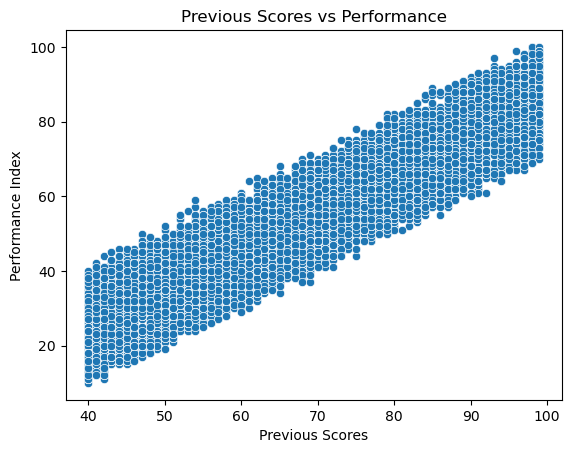

In [10]:
#PREVIOUS SCORES VS PERFORMANCE
sns.scatterplot(x="Previous Scores", y="Performance Index", data=df)
plt.title("Previous Scores vs Performance")
plt.show()

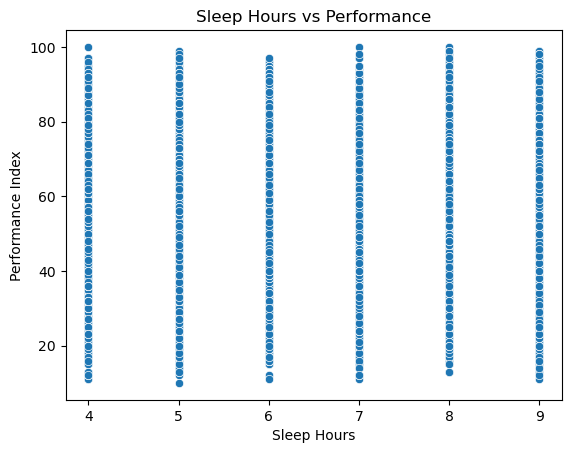

In [11]:
#SLEEP HOURS VS PERFORMANCE
sns.scatterplot(x="Sleep Hours", y="Performance Index", data=df)
plt.title("Sleep Hours vs Performance")
plt.show()

In [12]:
# DEFINING FEATURE AND TARGET
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

In [14]:
#TRAINING
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
#MODEL SELECTION
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
#EVALUATING MODEL
from sklearn.metrics import r2_score
pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9889832909573145


In [17]:
#Training RandomForest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
#Prediction of Random Forest
y_pred_rf = rf.predict(X_test)

In [20]:
#Evaluating 
from sklearn.metrics import mean_squared_error
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

Random Forest R2: 0.9860792088401176
MSE: 5.158838006796808


In [22]:
#MODELCOMPARISON
#LINEAR REGRESSION VS RANDOM FOREST
import pandas as pd
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, pred),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.988983
1,Random Forest,0.986079


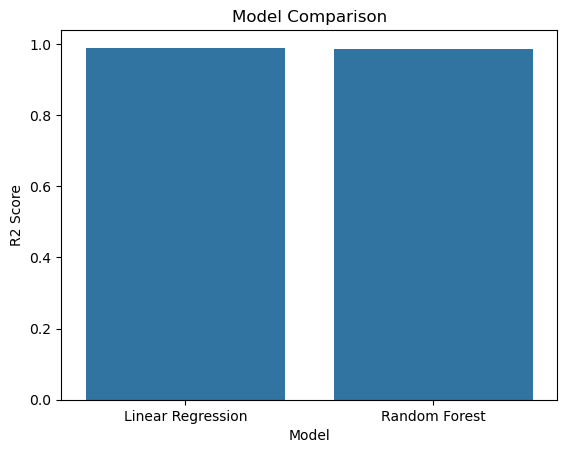

In [23]:
#MODEL PERFORMANCE VISUALISATION
import seaborn as sns
sns.barplot(x="Model", y="R2 Score", data=results)
plt.title("Model Comparison")
plt.show()

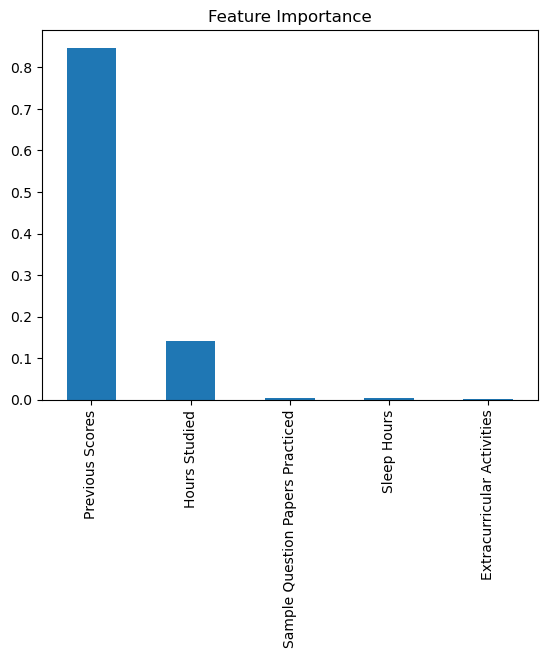

In [24]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind="bar")
plt.title("Feature Importance")
plt.show()

# PREVIOUS SCORES AND HOURS STUDIED HAS HIGHEST IMPACT

In [32]:
import pickle
pickle.dump(rf, open("../models/student_model.pkl", "wb"))


In [27]:
print("Linear Regression:", r2_score(y_test, pred))
print("Random Forest:", r2_score(y_test, y_pred_rf))
#LINEARREGRESSION was selected as best model due to slightly higher performance

Linear Regression: 0.9889832909573145
Random Forest: 0.9860792088401176


In [28]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [30]:
import streamlit as st
import numpy as np
import pickle

# Load model
model = pickle.load(open("../models/student_model.pkl", "rb"))

st.title("🎓 Student Performance Predictor")

st.write("Enter student details to predict performance index")

# Input fields
hours_studied = st.slider("Hours Studied", 0, 12, 5)
previous_scores = st.slider("Previous Scores", 0, 100, 50)
extracurricular = st.selectbox("Extracurricular Activities", ["Yes", "No"])
sleep_hours = st.slider("Sleep Hours", 0, 12, 6)
papers_practiced = st.slider("Sample Papers Practiced", 0, 10, 3)

# Convert categorical
extracurricular = 1 if extracurricular == "Yes" else 0

# Prediction
if st.button("Predict Performance"):
    input_data = np.array([[hours_studied, previous_scores, extracurricular, sleep_hours, papers_practiced]])
    
    prediction = model.predict(input_data)
    
    st.success(f"Predicted Performance Index: {prediction[0]:.2f}")

2026-03-17 10:27:31.630 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 10:27:32.464 
  command:

    streamlit run C:\Users\vinut\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-17 10:27:32.467 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 10:27:32.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 10:27:32.481 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 10:27:32.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 10:27:32.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-17 10:27:32.496 Thread 'MainThread': mi